# Credit Risk Analysis Project

**Name:** Anthony Mensah  
**Date:** March 11, 2026  
**Time:** 9:04 PM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In this section, the credit risk dataset is loaded into Python using the pandas library. 
This dataset contains borrower information such as loan amount, age, loan duration, 
and credit history which will be used to analyze credit risk.

In [2]:
df = pd.read_csv("credit.csv")
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [3]:
df.shape

(1000, 21)

In [4]:
df.columns

Index(['checking_balance', 'months_loan_duration', 'credit_history', 'purpose',
       'amount', 'savings_balance', 'employment_length', 'installment_rate',
       'personal_status', 'other_debtors', 'residence_history', 'property',
       'age', 'installment_plan', 'housing', 'existing_credits', 'default',
       'dependents', 'telephone', 'foreign_worker', 'job'],
      dtype='object')

## Data Preparation

The dataset is prepared for analysis by examining the target variable and converting 
the credit default column into a binary format suitable for machine learning models.

In [5]:
df['default'].value_counts()

default
1    700
2    300
Name: count, dtype: int64

In [6]:
df['default'] = df['default'].map({1:0, 2:1})

In [7]:
df['default'].value_counts()

default
0    700
1    300
Name: count, dtype: int64

## Exploratory Data Analysis

Exploratory analysis is performed to understand the distribution of loan defaults 
and identify patterns in borrower characteristics.

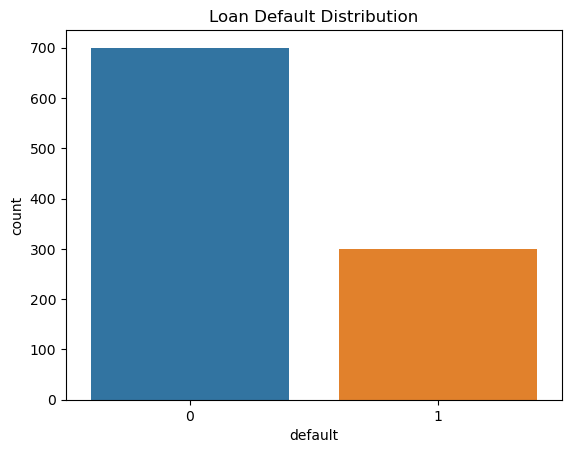

In [8]:
sns.countplot(x='default', data=df)

plt.title("Loan Default Distribution")

plt.show()

In [9]:
X = df[['amount', 'age', 'months_loan_duration']]
y = df['default']

## Model Training

A logistic regression model is trained to predict the probability that a borrower 
will default on a loan based on selected borrower characteristics.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Model Evaluation

The model's performance is evaluated using prediction accuracy and a confusion matrix, 
which compares predicted loan outcomes with actual outcomes.

In [12]:
predictions = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.73


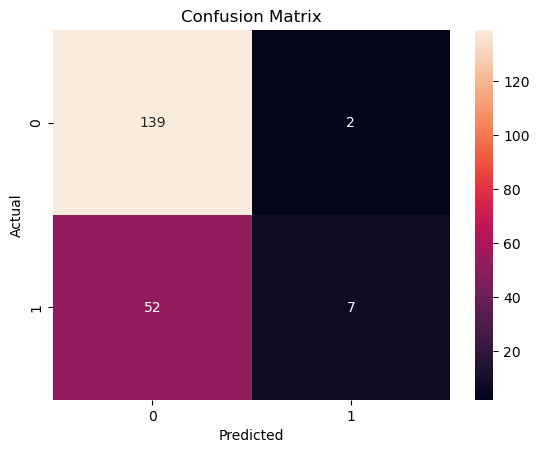

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Conclusion

This project analyzed borrower credit risk using variables such as loan amount, age, and loan duration. A logistic regression model was used to predict whether a borrower would default on a loan. The model achieved an accuracy of approximately 73%, demonstrating that borrower characteristics can help identify potential credit risk.